In [ ]:
# Preamble
import networkx as nx
from itertools import permutations
import matplotlib.pyplot as plt
import random
import io, contextlib
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist
import heapq

# MT3510 Pure Team Project


## Introduction

## Coding Tasks Part 1: Synchronization

### 1 (a): Test by searching the transition monoid

In [ ]:
# check if all generators of a finite automaton are permutations of the state set (Caelan)

def all_generators_permutations(A):
    Q = A["Q"]
    Sigma = A.get("S") or A.get("Sigma")
    tau = A["tau"]
    states = sorted(Q)
    n = len(states)

    for a in Sigma:
        images = {tau[(q, a)] for q in states}  # (state, letter) tuple key
        if len(images) < n:
            return False

    return True


def compose(x,y):                       # Taking product of fta(ta * f) for ta in X
    return tuple(x[y[i]]for i in range(len(x)))

In [ ]:
# Check synchronization by BFS searching monoid (Alex)


def synchronizing_bfs(A):              # Input is the full DFA A.
    """
    Accepts DFA as given in Question
    Returns True/ False

    """""

    Q = A["Q"]                          # Isolating the states from A
    Sigma = A.get("S") or A.get("Sigma")
    tau = A['tau']                         # Isolating the transition monoid from A
    states = sorted(Q)                   # Sorting the states to make sure they are in a consistent order


    #values=list(t.values())             # Isolating the values from the tuples
    values = [tuple(tau[(q, a)] for q in states) for a in Sigma]
    copy_values=values[:]               # Making a copy of values so that values is not changed
    seen=set(copy_values)               # taking the unique values of copied values


    if all_generators_permutations(A):
        return False

    while copy_values:                  #cA loop repeating while queue has entries

        f=copy_values.pop(0)            # removes the first value in copied values and sets f to that value

        if len(set(f))==1:              # Checks if a constant transformation has been found
            print("A constant transformation has been found and it is: "+str(f))
            return str(f)                      # If a constant transformation is found then it is returned as a string


        for t_a in values:               # Repeating for length of values
            ft_a=compose(f,t_a)          # Composing transformations

            if ft_a not in seen:         # If this h is new then it is added to seen and copied values to the be reused as a new possible solution
                seen.add(ft_a)
                copy_values.append(ft_a)
    return False                        # If after iterating through no transformation is found return false

### 1 (b): Images search synchronization
Test if a given DFA $\mathcal{A}$ is synchronizing by using breadth-first search to find an image of size 1, if it exists.

In [ ]:
# BFS images method (Alfie)


#bfs image function
def synchronizing_bfs_image(A):
    """
    Accepts DFA as given in Question
    Returns True/ False

    """""

    Q = tuple(sorted(A["Q"]))
    tau = A["tau"]
    Sigma = A.get("Sigma")

    if all_generators_permutations(A):   # Early exit: if all letters induce permutations, the monoid is a
        return False                     # permutation group and no synchronizing word can exist


    queue = deque([Q])
    seen = {Q}

    while queue:
        current_Q = queue.popleft()
        if len(current_Q) == 1:
            print("Synchronizing state found:", current_Q)
            return True
        for a in Sigma:
            new_Q = tuple(sorted({tau[(q, a)] for q in current_Q}))    # changed for consistency
            if new_Q not in seen:
                print(f"Visited tuple {new_Q} for the first time")
                seen.add(new_Q)
                queue.append(new_Q)

    return False


#### Algorithm Refinement

The standard BFS in 1(b) explores images in order of the word length used to reach them, treating all images of the same depth equally regardless of their
size. This raises a natural question: if we always prioritise smaller images, can we reach a singleton faster? The priority queue variant investigates this
by replacing the `deque` with a min-heap, so that the smallest currently known image is always expanded next rather than the oldest.

The algorithm is written to;

1. Initialise the heap with the full state set $Q$, wrapped as `(len(Q), Q)` so that heap ordering is determined by image size
2. Pop the smallest image from the heap, if it is a singleton return `True`
3. For each letter $a \in \Sigma$, compute the image
$T' = \{\tau(q, a) : q \in T\}$ as a sorted tuple 4. If $T'$ has not been seen before, add it to `seen` and push `(len(T'), T')` onto the heap
5. If the heap is exhausted without finding a singleton, return `False`

The tradeoff explored here is whether the more directed search strategy justifies the higher per-operation cost of heap operations compared to a plain deque, and whether prioritising by image size produces shorter reset words, longer ones, or none at all compared to standard BFS.

In [ ]:
# Priority queue search (Alfie)

def synchronization_pq_image(A):
    Q = tuple(sorted(A["Q"]))
    tau = A["tau"]
    Sigma = A["Sigma"]

    if all_generators_permutations(A):
        return False

    # Priority queue entries: (image_size, image_tuple)
    # heapq is a min-heap so smallest image size is always explored first
    pq = [(len(Q), Q)]
    seen = {Q}

    while pq:
        _, current_Q = heapq.heappop(pq)

        if len(current_Q) == 1:
            return True

        for a in Sigma:
            t_a = tau[a]
            new_Q = tuple(sorted({t_a[q] for q in current_Q}))
            if new_Q not in seen:
                seen.add(new_Q)
                heapq.heappush(pq, (len(new_Q), new_Q))

    return False

### 1(c): Pair Graph Synchronization Test

We test if a DFA is synchronising by constructing its pair graph and performing a backward BFS. For each pair of states $\{q_1, q_2\}$ and each letter $a \in \Sigma$, we compute the image pair $\{\tau(q_1, a), \tau(q_2, a)\}$. A pair is merged when both states map to the same state, producing a singleton. Rather than storing forward edges, we store reverse edges from each image pair back to its source pairs, allowing a single backward BFS from all singletons to simultaneously determine whether every pair can be merged.

In [ ]:
# synchronizing pair graph method (Alfie)

def synchronizing_pair_graph(A):
    """
    Accepts DFA as given in Question
    Returns True/ False

    """""

    Q = A["Q"]
    Sigma = A.get("S") or A.get("Sigma")  # changed
    tau = A["tau"]
    qs = A["q_s"]
    F = A["F"]

    # Each pair is stored as a frozenset so {q1,q2} == {q2,q1}
    # {q,q} then automatically becomes a singleton

    all_pairs = set()
    for q1 in Q:
        for q2 in Q:
            all_pairs.add(frozenset({q1, q2}))

    singletons = set()
    for node in all_pairs:
        if len(node) == 1:
            singletons.add(node)

    # For each pair and each letter find the image
    # Store the reverse: result <-- pair

    reverse_edges = {node: set() for node in all_pairs}
    for node in all_pairs:
        node_list = list(node)
        if len(node_list) == 1:
            q1, q2 = node_list[0], node_list[0]
        else:
            q1, q2 = node_list[0], node_list[1]

        for a in Sigma:
            target = frozenset({tau[(q1, a)], tau[(q2, a)]})  # changed
            reverse_edges[target].add(node)

    # Flood backwards from singletons merging pairs

    visited = set(singletons)
    queue = list(singletons)

    while queue:
        current = queue.pop(0)
        for neighbour in reverse_edges[current]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)

    # Check every non-singleton pair was reached
    # If so, every pair can be merged and a reset word exists

    non_singletons = all_pairs - singletons

    return non_singletons.issubset(visited)



In [ ]:
# Q1 Test cell part (a) (b) (c)

# A is not synchronizing
A = {
    "Q": {0, 1, 2}, "Sigma": {"a", "b"},
    "tau": {(0,"a"):1,(1,"a"):2,(2,"a"):0, (0,"b"):0,(1,"b"):1,(2,"b"):2},
    "q_s": 0, "F": {0}
}
# B is synchronizing
B = {
    "Q": {0, 1, 2}, "Sigma": {"a", "b"},
    "tau": {(0,"a"):1,(1,"a"):2,(2,"a"):0, (0,"b"):0,(1,"b"):0,(2,"b"):0},
    "q_s": 0, "F": {0}
}
# C is synchronizing
C = {
    "Q": {0, 1, 2, 3, 4}, "Sigma": {"a", "b"},
    "tau": {(0,"a"):1,(1,"a"):2,(2,"a"):3,(3,"a"):4,(4,"a"):0,
            (0,"b"):0,(1,"b"):1,(2,"b"):2,(3,"b"):3,(4,"b"):0},
    "q_s": 0, "F": {0}
}
# P is not synchronizing
P = {
    "Q": {0, 1, 2}, "Sigma": {"a"},
    "tau": {(0,"a"):1,(1,"a"):2,(2,"a"):0},
    "q_s": 0, "F": {0}
}

test_cases = [
    ("A — not synchronizing (b is identity)",     A, False),
    ("B — synchronizing (b collapses all)",       B, True),
    ("C — synchronizing (5-state, cyclic+merge)", C, True),
    ("P — not synchronizing (permutation group)", P, False),
]

# standardise functions
functions = {
    "synchronization_bfs":       lambda A: bool(synchronizing_bfs(A)),
    "synchronization_bfs_image": lambda A: bool(synchronizing_bfs_image(A)),
    "synchronizing_pair_graph":  lambda A: bool(synchronizing_pair_graph(A)),
}

# compare all outputs and print results

all_passed = True
for name, dfa, expected in test_cases:
    print(f"\n── {name}  (expected: {expected}) ──")
    for fn_name, fn in functions.items():
        buf = io.StringIO()
        with contextlib.redirect_stdout(buf):
            result = fn(dfa)
        ok = result == expected
        print(f"  {'ALL CLEAR' if ok else 'MISMATCH'} {fn_name}: {result}")
        if not ok:
            all_passed = False

print(f"\n{'ALL TESTS PASSED' if all_passed else 'SOME TESTS FAILED'}")



── A — not synchronizing (b is identity)  (expected: False) ──
  ALL CLEAR synchronization_bfs: False
  ALL CLEAR synchronization_bfs_image: False
  ALL CLEAR synchronizing_pair_graph: False

── B — synchronizing (b collapses all)  (expected: True) ──
  ALL CLEAR synchronization_bfs: True
  ALL CLEAR synchronization_bfs_image: True
  ALL CLEAR synchronizing_pair_graph: True

── C — synchronizing (5-state, cyclic+merge)  (expected: True) ──
  ALL CLEAR synchronization_bfs: True
  ALL CLEAR synchronization_bfs_image: True
  ALL CLEAR synchronizing_pair_graph: True

── P — not synchronizing (permutation group)  (expected: False) ──
  ALL CLEAR synchronization_bfs: False
  ALL CLEAR synchronization_bfs_image: False
  ALL CLEAR synchronizing_pair_graph: False

ALL TESTS PASSED


### 1 (d): Ancestors method bfs image search reset word

### Overview
The BFS image method with word recovery extends the basic synchronization check from Part (b) to not only determine *if* a reset word exists, but to actually reconstruct the *shortest* such word. This guarantees minimal length because BFS explores states in order of increasing word length.

In [ ]:
# bfs images sync with word retrieval (Alfie)

def synchronizing_bfs_word(A):
    Q = tuple(sorted(A["Q"]))
    tau = A["tau"]
    Sigma = A["Sigma"]

    # Early exit: permutation monoid can never synchronize
    if all_generators_permutations(A):
        return None

    # ancestor maps each tuple -> (parent_tuple, letter_used_to_get_here)

    ancestor = {Q: (-1, None)}

    queue = [Q]
    i = 0

    while i < len(queue):
        current_Q = queue[i]
        i += 1

        for a in Sigma:
            new_Q = tuple(sorted({tau[(q, a)] for q in current_Q}))

            # Only visit new_Q if we haven't seen it yet
            if new_Q not in ancestor:
                ancestor[new_Q] = (current_Q, a)  # record tuple and letter used

                # If we've reached a singleton, trace back to get the word
                if len(new_Q) == 1:
                    word = []
                    current = new_Q
                    # Walk back through ancestors until we hit the sentinel -1
                    while ancestor[current][0] != -1:
                        parent, letter = ancestor[current]
                        word.append(letter)
                        current = parent
                    #BFS traces from singleton back to root, so letters accumulate in reverse order`
                    word.reverse()
                    return word

                queue.append(new_Q)

    return None  # No synchronizing word exists

### 1 (e): Have your pair-graph method return a reset word if one exists.

In [ ]:
# synchronizing pair graph with word retrieval (Alfie)

def synchronizing_pair_graph_word(A):
    Q = A["Q"]
    Sigma = A.get("S") or A.get("Sigma")
    tau = A["tau"]

    # Early exit: permutation monoid can never synchronize
    if all_generators_permutations(A):
        return False

    all_pairs = {frozenset({q1, q2}) for q1 in Q for q2 in Q}
    singletons = {node for node in all_pairs if len(node) == 1}

    reverse_edges = {node: [] for node in all_pairs}
    for node in all_pairs:
        node_list = list(node)
        q1, q2 = (node_list[0], node_list[0]) if len(node_list) == 1 else (node_list[0], node_list[1])
        for a in Sigma:
            target = frozenset({tau[(q1, a)], tau[(q2, a)]})  # changed
            reverse_edges[target].append((node, a))

    ancestor = {node: (-1, None) for node in singletons}
    queue = deque(singletons)
    while queue:
        current = queue.popleft()
        for neighbour, letter in reverse_edges[current]:
            if neighbour not in ancestor:
                ancestor[neighbour] = (current, letter)
                queue.append(neighbour)

    if not (all_pairs - singletons).issubset(ancestor.keys()):
        return None

    def merging_word(pair):
        word = []
        current = pair
        while ancestor[current][0] != -1:
            child, letter = ancestor[current]
            word.append(letter)
            current = child
        return word

    def apply_word(states, word):
        for letter in word:
            states = {tau[(q, letter)] for q in states}  # changed
        return states

    current_states = set(Q)
    full_word = []
    while len(current_states) > 1:
        states_list = list(current_states)
        pair = frozenset({states_list[0], states_list[1]})
        word = merging_word(pair)
        full_word.extend(word)
        current_states = apply_word(current_states, word)
    return full_word


In [ ]:
# Test Cell for part (d) (e)
print(f"{synchronizing_pair_graph_word(C)} \n {synchronizing_bfs_word(C)}")

['a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b'] 
 ['b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b']


### 1 (f): Investigate a "heuristic"

In [ ]:
# Shortening word heuristic (Alfie)


def still_synchronizes(A, word):
    # Apply word to all states and check if result is a singleton
    states = set(A["Q"])
    tau = A["tau"]
    for letter in word:
        states = {tau[letter][q] for q in states}
    return len(states) == 1

def trim_word(A, word):
    trimmed = word[:]
    i = len(trimmed) - 1
    while i >= 0:
        candidate = trimmed[:i] + trimmed[i+1:]
        if still_synchronizes(A, candidate):
            trimmed = candidate
            i = min(i, len(trimmed) - 1)
        else:
            i -= 1                    # letter i is needed, try the one before it
    return trimmed


In [ ]:
word_d = synchronizing_bfs_word(B)
word_e = synchronizing_pair_graph_word(B)

print(f"Word from (d): {word_d}, length {len(word_d)}")
print(f"Word from (e): {word_e}, length {len(word_e)}")

trimmed = trim_word(B, word_e)

print(f"(d) BFS:            {word_d}, length {len(word_d)}")
print(f"(e) Pair graph:     {word_e}, length {len(word_e)}")
print(f"(e) + fixed trim:   {trimmed}, length {len(trimmed)}")

Word from (d): ['b'], length 1
Word from (e): ['b'], length 1
(d) BFS:            ['b'], length 1
(e) Pair graph:     ['b'], length 1
(e) + fixed trim:   ['b'], length 1


### Q1 - Probability that a uniformly chosen DFA is synchronizing.

A **uniformly-chosen** DFA with $n$ states over an alphabet $\Sigma$ of size $k$ is one where each transition $\tau(q, a)$ is drawn independently and uniformly at random from $Q$.

We estimate the probability
$$P_k(n) = \mathbb{P}[\text{random DFA with } n \text{ states, } |\Sigma|=k \text{ is synchronizing}]$$
by random (probably Monte Carlo) sampling: for each $(n, k)$ pair we sample $M$ random DFAs and record the fraction that are synchronizing.

**Known theoretical result:** For any fixed $k \geq 2$, $P_k(n) \to 1$ as $n \to \infty$  almost all large DFAs are synchronizing. Larger alphabets accelerate convergence.

We also plot 95% Binomial confidence intervals to quantify estimation uncertainty.

In [ ]:
# Uniformly chosed DFA generator (Caelan)

def random_dfa(n, k):  # uniformly chosen DFA

    Q = set(range(n))
    Sigma = list(range(k))

    # tau[(q, a)] = delta(q, a)
    tau = {(q, a): random.randint(0, n - 1) for q in range(n) for a in Sigma}

    return {"Q": Q, "S": Sigma, "tau": tau, "q_s": 0, "F": set()}


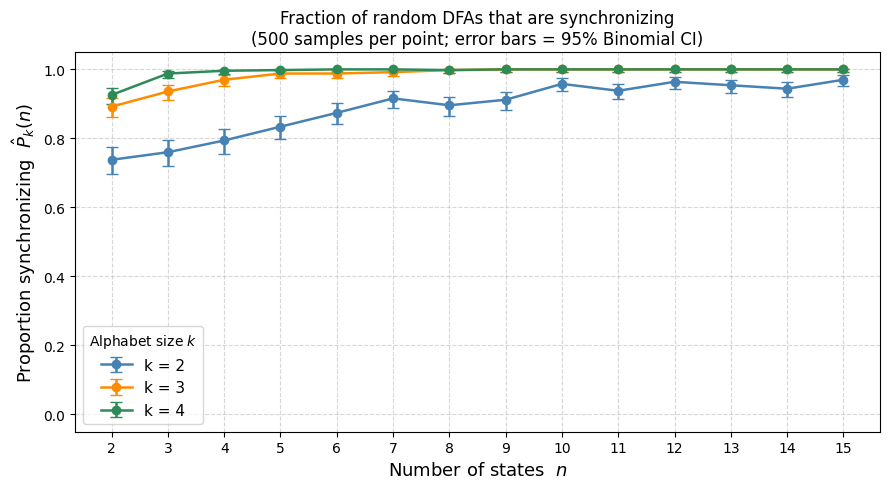

In [ ]:
# Visualisation of synchronizing DFA proportions (Caelan)

def confidence_interval(successes, trials, alpha=0.05):
    """Return (lower, upper) 95% binomial confidence interval."""
    lo = beta_dist.ppf(alpha / 2,     successes,         trials - successes + 1)
    hi = beta_dist.ppf(1 - alpha / 2, successes + 1,     trials - successes)
    lo = 0.0 if np.isnan(lo) else lo
    hi = 1.0 if np.isnan(hi) else hi
    return lo, hi


state_counts = list(range(2, 16))   # n = 2, 3, ..., 15
alphabet_sizes = [2, 3, 4]          # k values to compare
M = 500                             # DFAs sampled per (n, k) pair

random.seed(42)
results = {}                         # results[(k, n)] = (proportion, lo, hi)

for k in alphabet_sizes:            # check if dfa is synchronizing over parameter space
    for n in state_counts:
        sync_count = sum(
            bool(synchronizing_pair_graph(random_dfa(n, k)))
            for _ in range(M)
        )
        p_hat = sync_count / M
        lo, hi = confidence_interval(sync_count, M)
        results[(k, n)] = (p_hat, lo, hi)

# plot
fig, ax = plt.subplots(figsize=(9, 5))
colors = {2: "steelblue", 3: "darkorange", 4: "seagreen"}

for k in alphabet_sizes:
    ns      = state_counts
    p_hats  = [results[(k, n)][0] for n in ns]
    lowers  = [results[(k, n)][1] for n in ns]
    uppers  = [results[(k, n)][2] for n in ns]
    errs    = [
        [p - lo for p, lo in zip(p_hats, lowers)],
        [hi - p for p, hi in zip(p_hats, uppers)],
    ]
    ax.errorbar(ns, p_hats, yerr=errs,
                marker="o", capsize=4, label=f"k = {k}",
                color=colors[k], linewidth=1.8)

ax.set_xlabel("Number of states  $n$", fontsize=13)
ax.set_ylabel("Proportion synchronizing  $\\hat{P}_k(n)$", fontsize=13)
ax.set_title(f"Fraction of random DFAs that are synchronizing\n"
            f"({M} samples per point; error bars = 95% Binomial CI)",
            fontsize=12)
ax.legend(title="Alphabet size $k$", fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(state_counts)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Coding Tasks Part 2: Isomorphism

###Background
The main aim of our section is to decide whether two DFA’s have the same transition structure up to relabelling. In this portion we considered three increasingly weaker notions of equivalence: strict isomorphism, weak isomorphism and semi-isomorphism.

Strict isomorphism preserves the entire DFA structure: states may be relabelled, but the start state, accepting states, and alphabet must be respected exactly. Weak isomorphism is more flexible, allowing both the states and the alphabet symbols to be relabelled, while still preserving start and accepting states. Semi-isomorphism weakens this further by ignoring the start and accepting states entirely and only requiring preservation of the underlying labelled transition structure up to relabelling of both states and letters.

We were asked to write three functions, strict_isom, weak_isom and semi_isom, which take two DFAs and check whether they are strictly, weakly, or semi-isomorphic.

Computationally, the challenge is to design code that is correct, readable, and efficient enough to handle nontrivial examples. Our implementation solves this by combining backtracking with early structural checks, this means impossible mappings are rejected before the full search space is explored.

###Algorithm
Each function starts by calling the general function, **isom_check**, which tries to find bijections satisfying the conditions for the specified isomorphic type and returns a boolean.  

**Isom_check** first weeds out DFAs which violate the structural conditions for bijections and isomorphisms. It ensures that the DFAs have an equal number of states and letters and that, if searching for a strict isomorphism, the alphabets are equal, before doing any recursion. This avoids unnecessary recursive searches.

Next, **Isom_check** constructs a mapping between states **f: Q1 -> Q2** and a mapping between letters **g: E1 -> E2** depending on the specifications.  For example, the initial state mappings for **strict_isom** and **weak_isom** are formed by the start states **qs1** and **qs2** whereas the start states are ignored in **semi-isom**. Instead, a helper func, **get_source_states**, finds the source states of the DFAs and tries to construct a bijection for every combination of source states as the initial mapping.  Using a helper func improves semi_isom’s readability.  For **strict_isom**, we know that **g** is the identity func as **E1** and **E2** are equal.  However, for **weak_isom** and **semi_isom**, we must try to build bijections from **E1** to any permutation of **E2**.  

**Isom_check** does this using the backtracking functions **explore_states** and **explore_letters**. **Explore_states** tries to extend **f**  to a bijection satisfying the specified conditions. The function recursively explores possible mappings between states by updating the current partial mapping **f** and checking that the transitions remain constant under the current mappings, backtracking whenever a mapping violates the isomorphic conditions.  This is more efficient than generating every complete bijection upfront.  **Explore_states** starts by checking that a solution has not already been found. Then **explore_states** weeds out invalid mappings before recursion by seeing if the number of distinct states reachable from each state is unequal or, for **strict_isom** and **weak_isom**, only one state is a start state or an accepting state.  If checking for a weak or **semi-isomorphism**, **explore_states** uses **explore_letters** to construct a suitable bijection between the alphabets of the DFAs while preserving transition consistency with the current state mapping by recursively exploring letter mappings.

Both backtracking functions check consistency with the helper functions **consistent_pair**, which checks that a single mapping is consistent, and **consistent_transitions**, which checks that all transitions remain consistent under the updated state and letter mappings.

Separate helper functions such as these and universal functions such as **isom_check**, **explore_states** and **explore_letters** help readability and decrease the amount of repeated code. By isolating mode-specific logic in the initial conditions and moving shared functionality into helper functions, the algorithm more clearly reflects the underlying mathematical structure of the problem, making it easier to understand.


In [1]:
# Chek ismorophism of DFAs (Penelope & Rhiannon)

def check_isom(A1, A2, mode):
    """
    Check whether two DFAs are strictly, weakly, or semi-isomorphic

    Parameters:
    - A1: 5-tuple forming a DFA
    - A2: 5-tuple forming a DFA
    - mode: String specifying what specific type of isomorphism to check for

    Returns:
    A boolean that equals True if the two DFAs are the specified type of isomorphic & False if they are not
    """

    #For each DFA, unpack the 5-tuple & store the states Q, alphabet letters E, transition func T, starting state qs & accepting states F
    Q1, E1, T1, qs1, F1 = A1
    Q2, E2, T2, qs2, F2 = A2

    if len(Q1) != len(Q2): #check that A1 & A2 have equal # of states nessesary for a bijection
            return False
    if mode == "strict" and E1 != E2: #if checking for strict isom, check that alphabets E1 & E2 are equal
            return False
    elif len(E1) != len(E2): #if checking for weak or semi isom, check that alphabets E1 & E2 are equal size
            return False

    def get_source_states(A):
        """
        Find the source states of a DFAs transition graph

        Parameters:
        - A: 5-tuple forming a DFA

        Returns:
        A list containing the source states of a DFAs transition graph
        """
        #unpack the 5-tuple forming A
        Q, E, T, qs, F = A

        #create directed graph to show transitions structure of DFA
        G = nx.DiGraph()
        G.add_nodes_from(Q)
        for (q, a), r in T.items():
            G.add_edge(q,r)

        #sort states into groups where every state can reach every other state by following transitions & store in directed graph as nodes
        C = nx.condensation(G)

        #create list to store source states belonging to these groups
        sources = []
        #for each group
        for node in C.nodes:
            if C.in_degree(node) == 0: #if there are no groups that transition into this group
                sources.extend(C.nodes[node]['members']) #add these to the list of source states

        return sources

    def explore_states(f, g, seen_states, seen_letters):
        """
        Try to construct a suitable bijection between states of the DFAs
        Recursively explore possible mappings between states by updating the current partial bijection f and checking that transitions remain consistent,
        backtracking whenever a mapping violates the isomorphism conditions

        Parameters:
        - f: A partial bijection between states
        - g: A partial bijection between letters
        - seen_states: A set of states in Q2 that have already been mapped to by f
        - seen_letters: A set of letters in E2 that have already been mapped to by g

        Returns:
        A boolean that equals True if bijections between states & between alphabets satisfying the isomorphic conditons are found & False if not
        """

        if len(f) == len(Q1): #check if state mapping f is a complete bijection
            return True

        #for each unmapped state q in Q1
        for q in Q1:
            if q not in f:
                break

        #try mapping q to every unseen state in Q2
        for s in Q2:
            if s in seen_states:
                continue

            if len({T1[(q,a)] for a in E1}) != len({T2[(s,b)] for b in E2}): #check that # of distinct states reachable from q & s are equal
                continue #this reduces the # of mappings explored by removing those that cannot form a bijection

            if mode != "semi": #if checking for strict or weak isom

                if (q in F1) != (s in F2): #check that states q & s are both accepting or both not accepting
                    continue #this reduces the # of mappings explored by removing those that fail the conditions

                if q == qs1 and s != qs2: #check that states q & s are both starting states or both not starting
                    continue

            f[q] = s #temporarily map q to state s via f
            seen_states.add(s) #& add s to seen states

            if mode == "strict": #if checking for strict isom

                if consistent_transitions(f,g): #consistency check the updated state mapping f
                    if explore_states(f, g, seen_states, seen_letters): #then try mapping remaining states in Q1
                        return True

            else: #if checking for weak or semi isom

                if explore_letters(f, g, q, s, seen_letters): #try mapping the letters corresponding to these states & consistency check the updated state & letter mappings f & g
                    if explore_states(f, g, seen_states, seen_letters): #then try mapping remaining states in Q1
                        return True

            #if the updated state & letter mappings f & g are inconsistent, backtrack & try the next unseen state in Q2
            del f[q]
            seen_states.remove(s)

        return False


    def explore_letters(f, g, q, s, seen_letters):
        """
        Try to construct a suitable bijection between the alphabets of the DFAs
        while preserving transition concistency with the current state mapping by recursively exploring letter mappings

        Parameters:
        - f: A partial bijection between states
        - g: A partial bijection between letters
        - q: A state in Q1
        - s: A state in Q2
        - seen_letters: A set of letters in E2 that have already been mapped to by g

        Returns:
        A boolean that equals True if a bijection satisfying these conditions is found & False if not
        """

        #for each letter a in E1
        for a in E1:
            if a in g: #if g already maps a to a letter in E2
                b = g[a]

                if not consistent_pair(f, g, q, s, a, b): #consistency check the mapped pair under the current state mapping f & letter mapping g
                    return False

            else: #if a is not already mapped to a letter in E2

                #try mapping a to every unseen letter b in E2
                for b in E2:
                    if b in seen_letters:
                        continue

                    g[a] = b #temporarily map a to letter b in E2 via g
                    seen_letters.add(b) #& add b to seen letters

                    if consistent_pair(f, g, q, s, a, b): #consistency check the mapped pair under the current state mapping f & letter mapping g
                        if explore_letters(f, g, q, s, seen_letters): #then try mapping the remaining letters in E1
                            return True

                    #if the updated state & letter mappings f & g are inconsistent, backtrack & try the next unseen letter in E2
                    del g[a]
                    seen_letters.remove(b)
                return False
        return True

    def consistent_pair(f, g, q, s, a, b):
        """
        Given a mapped pair, check that their single transition mapping is consistent with the current state mapping f & letter mapping g

        Parameters:
        - f: A partial bijection between states
        - g: A partial bijection between letters
        - q: A state in Q1
        - s: A state in Q2 mapped to q via f
        - a: A letter in E1
        - b: A letter in E2 mapped to a via g

        Returns:
        A boolean that equals True if the single transition is consistent & False if not
        """

        #find & store T1(q,a) & T2(f(q),g(a))
        t1 = T1[(q,a)]
        t2 = T2[(s,b)]

        #check that f(T1(q,a)) is not already mapped to a state other than T2(f(q),g(a))
        #forward check
        if t1 in f and f[t1] != t2:
            return False
        #reverse check
        for q2, s2 in f.items():
            if T1.get((q2,a)) == q and T2.get((s2, b)) != s:
                return False
        return True

    def consistent_transitions(f, g):
        """
        Check that all transitions remain consistent under the updated state & letter mappings f & g

        Parameters:
        - f: A partial bijection between states
        - g: A partial bijection between letters

        Returns:
        A boolean that equals True if the transitions are consistent & False if not
        """
        #for each pair of mapped state & letter
        for q in f:

            for a in E1:
                if a not in g:
                    continue
                b = g[a]
                if not consistent_pair(f, g, q, f[q], a, b): #& check that their transition is consistent with the current state mapping f & letter mapping g
                    return False
        return True

    if mode == "strict": #if checking for strict

        f = {qs1 : qs2} #create bijection f with initial mapping from qs1 to qs2
        seen_states = {qs2} #create set to keep track of states in Q2 that have already been mapped to by f & add qs2

        g = {a: a for a in E1} #create bijection g for mapping letters from E1 to E2
        seen_letters = set() #create set to keep track of letters in E2 that have already been mapped to by g

        #try finding bijections f & g that satisfy the conditions given the DFA
        return explore_states(f, g, seen_states, seen_letters)

    elif mode == "weak": #if checking for weak

        #sort the alphabets to later index
        letters1 = sorted(E1)
        letters2 = sorted(E2)

        #for every possible bijection g mapping letters from E1 to E2
        for perm in permutations(letters2):

            f = {qs1 : qs2} #create bijection f with initial mapping from qs1 to qs2
            seen_states = {qs2} #create set to keep track of states in Q2 that have already been mapped to by f & add qs2

            g = {letters1[i]: perm[i] for i in range(len(letters1))} #store the bijection g by indexing the uniquely ordered letters in E2
            seen_letters = set() #create set to keep track of letters in E2 that have already been mapped to by g

            #try finding bijections f & g that satisfy the conditions given the DFA
            if explore_states(f, g, seen_states, seen_letters):
                return True
        return False

    elif mode == "semi":
        #find the source states of A1 & A2
        sources1 = get_source_states(A1)
        sources2 = get_source_states(A2)

        #sort the alphabets to later index
        letters1 = sorted(E1)
        letters2 = sorted(E2)

        #for every possible bijection g mapping letters from E1 to E2
        for perm in permutations(letters2):

            g = {letters1[i]: perm[i] for i in range(len(letters1))} #store the bijection g by indexing the uniquely ordered letters in E2

            #then for each pair of source states q & s
            for q in sources1:
                for s in sources2:

                    f = {q:s} #create bijection f with initial mapping from q to s
                    seen_states = {s} #create set to keep track of states in Q2 that have already been mapped to by f & add s

                    seen_letters = set() #create set to keep track of letters in E2 that have already been mapped to by g

                    #try finding bijections f & g that satisfy the conditions given the DFA
                    if explore_states(f, g, seen_states, seen_letters):
                        return True
    return False

### 2 (a): Strict isomorphism

In [2]:
def strict_isom(A1, A2):
    # --------------------------------
    # Check whether two DFAs are strictly isomorphic i.e. if there is a bijection f: Q1 -> Q2 s.t.
    # T2(f(q), a) = f(T1(q, a)) for all q in Q1 & a in E1
    # f(qs1) = qs2
    # f(F1) = F2
    # The alphabet is the same & unchanged
    # --------------------------------
    return check_isom(A1, A2, "strict")


### 2 (b): Weak isomorphism

In [3]:
def weak_isom(A1, A2):
    # --------------------------------
    # Check whether two DFAs are weakly isomorphic i.e. if there are bijections f: Q1 -> Q2 & g: E1 -> E2 s.t.
    # T2(f(q), g(a)) = f(T1(q, a)) for all q in Q1 & a in E1
    # f(qs1) = qs2
    # f(F1) = F2
    # --------------------------------
    return check_isom(A1, A2, "weak")

### 2 (c): Semi-isomorphism

In [4]:
def semi_isom(A1, A2):
    # --------------------------------
    # Check whether two DFAs are semi-isomorphic i.e. if there are bijections f: Q1 -> Q2 & g: E1 -> E2 s.t.
    # T2(f(q), g(a)) = f(T1(q, a)) for all q in Q1 & a in E1
    # --------------------------------
    return check_isom(A1, A2, "semi")

###Development & Testing
These functions underwent significant changes and improvements.

Originally, **semi_isom** tried to build bijections by trying all possible pairs of anchor states using two nested for loops. To increase efficiency, we instead grouped states into strongly connected components, where each state in a group can reach every other state through transitions.  These groups are represented as nodes in a condensation graph.  Those with no incoming edges contain the source states of the DFA. Therefore, the improved algorithm only tries pairs of source states as initial mappings because any valid semi-isomorphism must respect this high-level source structure. This drastically reduces the search space for **semi_isom**.

Initial versions of our code repeated the initial conditionals, search setup, and consistency checks for each wrapper function, **strict_isom**, **weak_isom**, and **semi_isom**, only calling on a single shared backtrack function.  This backtrack function relied on many parameters including clunky booleans such as **check_start** and **check_final**.  While functional, the increased number of repeated lines and variables greatly diminished efficiency and readability.  Hence, the code was reorganised around a universal function, **check_isom**, ensuring that common structure only appeared once and implementation of helper functions was more concise and clear.

Furthermore, **explore_states** repeatedly searched for unmapped states in **Q1** using a for loop and if conditional. However, first assigning the states in a fixed order and then mapping them sequentially decreased scanning and overhead from recursion.  

Initially, a single func **consistent_check** ensured that only the newest mapping satisfied the conditions. To ensure that all existing pairs stayed consistent whenever a mapping was added, the function, **consistent_transitions**, which repeatedly used **consistent_check**  (renamed **consistent_pair**), was made.  This prevented invalid mappings from propagating deeper into recursion.  

Additionally, **Consistent_pair** initially checked that the mapping satisfied the conditions in the forward direction, that is, the outgoing transitions matched and **T1(q,a)** and **T2(f(q),g(a))**.  But adding a reverse check, which checked incoming transitions by looking at all already mapped states and checking that any state that maps into **q** also maps into **f(q)**, helped detect invalid mappings earlier and reduced the recursion depth.

We tested our code on different example DFAs, including edge cases, using functions we wrote which generated random DFAs that were strictly, weakly, semi, and non-isomorphic to a given DFA.  Initial testing gave us the output we expected and additional example DFAs showed that these results were consistent.

**add CPU testing**

###Results
Here is the output from **strict_isom**, **weak_isom**, and **semi_isom** on four known DFAs against the DFA given in the project specifications **A1**.  **A2** is strictly isomorphic, **A3** is weakly isomorphic, and **A4** is semi-isomorphic, and **A4** is non-isomorphic to **A1**.

In [ ]:
#demonstration

As expected, the functions correctly identify strict, weak, semi, and non-isomorphisms.

In particular,
- The strict copy was identified as strict, weak, and semi-isomorphic,
- The weak copy was identified as weak and semi-isomorphic, but not strict,
- The semi copy was identified as semi-isomorphic only,
and the modified automaton was rejected as non-isomorphic.

This highlights the hierarchy between the three notions and shows that the program is not simply returning **True** for superficially similar DFAs, but distinguishing exactly which structural conditions are preserved.

**add analysis of computational time**

From a computational point of view, the results were also influenced by how much pruning the algorithm could do. Pairs of DFAs with obviously incompatible local structure were rejected quickly because the consistency checks and reachability-based filters ruled out bad mappings early. More symmetric DFAs, on the other hand, can generate larger search spaces because more candidate bijections remain plausible for longer.


### 2 (d): Discussion


In [5]:
# Q2 test cell (Penelope & Rhiannon)

#use example DFA from project background
# states {0,1,2,3}, alphabet {0,1}, start state 3, accepting {1,2}
A1 = (
    {0, 1, 2, 3},
    {0, 1},
    {(0,0):1, (0,1):0, (1,0):1, (1,1):0, (2,0):1, (2,1):2, (3,0):2, (3,1):0},
    3,
    {1, 2}
)

def random_strict_isom(A1):
    """
    Create a random DFA, A2, s.t. it is strictly isomorphic to the given DFA

    Parameters:
    - A1: 5-tuple forming a DFA

    Returns:
    A 5-tuple forming a DFA
    """
    #unpack DFA
    Q1, E1, T1, qs1, F1 = A1

    #convert states in Q1 to a list
    states = list(Q1)
    #create a copy of the list
    perm = states[:]
    #randomly shuffle this copy
    random.shuffle(perm)

    #create a bijection f mapping states in Q1 to shuffled states
    f = {states[i]: perm[i] for i in range(len(states))}

    #create new transition func, start states, and accepting states using f
    T2 = {(f[q], a): f[r] for (q,a), r in T1.items()}
    qs2 = f[qs1]
    F2 = {f[q] for q in F1}

    return (set(perm), E1, T2, qs2, F2)

def random_weak_isom(A1):
    """
    Create a random DFA, A2, s.t. it is weakly isomorphic to the given DFA

    Parameters:
    - A1: 5-tuple forming a DFA

    Returns:
    A 5-tuple forming a DFA
    """
    #unpack DFA
    Q1, E1, T1, qs1, F1 = A1

    #convert states in Q1 & letters in E1 to lists
    states = list(Q1)
    letters = list(E1)

    #create copies of these lists
    state_perm = states[:]
    letter_perm = letters[:]

    #randomly shuffle these copies
    random.shuffle(state_perm)
    while True: #while shuffling the letters, check that g is not the identity func
        random.shuffle(letter_perm)
        if any(letters[i] != letter_perm[i] for i in range(len(letters))):
            break

    #create a bijection f mapping states in Q1 to shuffled states
    f = {states[i]: state_perm[i] for i in range(len(states))}
    #create a bijection g mapping letters in E1 to shuffled letters
    g = {letters[i]: letter_perm[i] for i in range(len(letters))}

    #create new transition func, start states, & accepting states using f & g
    T2 = {(f[q], g[a]): f[r] for (q,a), r in T1.items()}
    qs2 = f[qs1]
    F2 = {f[q] for q in F1}

    return (set(state_perm), set(letter_perm), T2, qs2, F2)

def random_semi_isom(A1):
    """
    Create a random DFA, A2, s.t. it is semi-isomorphic to the given DFA

    Parameters:
    - A1: 5-tuple forming a DFA

    Returns:
    A 5-tuple forming a DFA
    """
    #unpack DFA
    Q1, E1, T1, qs1, F1 = A1

    #convert states in Q1 to a list
    states = list(Q1)

    while True:
        #randomly chose a start state
        qs2 = random.choice(states)
        #randomly sample accepting states from Q1 & store as F2
        n = random.randint(0, len(states))
        F2 = set(random.sample(states, n))
        if qs1 != qs2 or F1 != F2: #check that these never satisfy the conditions for strictly or weakly isom
            break

    return (Q1, E1, T1, qs2, F2)

print("Check two strictly isom DFAs:")
print(f"strict_isom: {strict_isom(A1, random_strict_isom(A1))}")
print(f"weak_isom: {weak_isom(A1, random_strict_isom(A1))}")
print(f"semi_isom: {semi_isom(A1, random_strict_isom(A1))}")

print("\n Check two weakly isom DFAs:")
print(f"strict_isom: {strict_isom(A1, random_weak_isom(A1))}")
print(f"weak_isom: {weak_isom(A1, random_weak_isom(A1))}")
print(f"semi_isom: {semi_isom(A1, random_weak_isom(A1))}")

print("\n Check two semi-isom DFAs:")
print(f"strict_isom: {strict_isom(A1, random_semi_isom(A1))}")
print(f"weak_isom: {weak_isom(A1, random_semi_isom(A1))}")
print(f"semi_isom: {semi_isom(A1, random_semi_isom(A1))}")

Check two strictly isom DFAs:


NameError: name 'random' is not defined

###Canonicalisation & Minimisation of DFAs
**add text**

###Roles
Rhiannon and Penelope decided to complete the first three isomorphic questions independently and combine our code into one final solution, taking the most efficient parts from either while maintaining readability. Rhiannon’s code had stronger backtracking structure, transition validation, and semi-isomorphic checks, while Penelope's had better alphabet mapping and identified structural violations earlier.

Penelope combined the solutions and found additional ways to opptimize efficenty and revised and rewrote the syntax and comments to create a clear readable format.

Rhiannon created DFAs that were known to be strictly, weakly, semi, and non-isomorphic to the example DFA.  Penelope then wrote functions to generate more random DFAs for testing.

**add CPU testing roles**

Rhiannon focused on answering the final isomorphic question.

**add originality roles**

Both Rhiannon and Penelope outlined and combined individual teammates thoughts into the final report.  Penelope wrote the sections for part 2, with Rhiannon's input, while Rhiannon wrote the general introduction and mathematical background.

# Disclosure on the usage of AI

To help compare Penelope and Rhiannon's algorithms for part 2, we breifly consulted AI, asking it to identify example where one was more efficient than the other.